# Raw data exploration

Walks through the **raw CSVs** as they live on disk under
`data/raw/{pd,lgd}/<dataset_id>.csv` — *before* any surgical fix
or sanitisation. The story this notebook tells is *what did the
vendor actually deliver?*

**Designed for the 3 000-dataset corpus.** Every plot is a
corpus-level histogram or a sortable table — nothing iterates
through individual feature columns.

## What 'missingness' means here

Throughout the project, `missing_rate` (also `missing_cells_rate`
in raw view) is the **fraction of cells** that are NaN, with
`cell_count = n_rows × n_features`. It is *not* the fraction of
rows that contain at least one NaN. A row with 3 NaN cells out
of 50 features contributes 3 to the cell count, not 1.

## What 'source' means here

Every dataset carries a free-text `source` field — values like
`"kaggle"`, `"uci"`, `"freddie-mac"`, `"local"`,
`"hackerearth"`, `"lendingclub"`. These come from the
`DATASET_METADATA` dict literal in `src/data/preprocessing.py`,
where each dataset is registered by hand alongside its target
column and categorical hints. `register.py` carries the field
forward into the manifest verbatim, so it is the same across
all three notebook layers.

## Why the first cell takes a while (and the rest don't)

`raw_corpus_summary()` reads every raw CSV from disk to compute
shapes / missingness / file sizes. Two datasets are very wide
(`0014.algorithmwatch` is 159 k × 2 987, `0011.loan_default` is
105 k × 770), and `pd.read_csv` on those alone accounts for
~80 s. We **memoise the result** so every subsequent cell — every
plot — reuses the same DataFrame and runs in milliseconds. To
bust the cache after a fresh pipeline rebuild, pass
`refresh=True` to any of the corpus-summary calls, or run
`clear_summary_cache()` once.

## Sections

1. Cold-start: build the corpus summary table (memoised)
2. Per-track corpus shape (rows, features)
3. Per-track missingness
4. Per-dataset target distribution — LGD only (paginated)
5. Corpus-level target stats (PD class imbalance + LGD target mean)
6. Anomaly scan

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
REPO = Path(os.getcwd()).resolve()
while not (REPO / 'src' / 'data' / 'exploration.py').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import pandas as pd
from src.data.exploration import (
    raw_corpus_summary, clear_summary_cache,
    plot_dataset_size_distribution, plot_missing_rate_distribution,
    plot_class_imbalance_distribution, plot_target_mean_distribution_lgd,
    plot_target_distribution_lgd,
    find_anomalous_datasets,
)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

## 1. Build the summary table (memoised)

First call reads every raw CSV; takes ~90 s on the current
21-dataset corpus, scaling roughly linearly with cell count.
Subsequent calls (and every plot below) reuse the cached
DataFrame. Float columns are rounded to 4 decimals; file size
to 2 decimals.

In [2]:
raw_summary = raw_corpus_summary()      # cold start
raw_summary.sort_values(['track', 'raw_rows'])

,track,dataset_id,raw_rows,raw_cols,missing_cells_rate,file_mb,target_in_raw,raw_target_unique,source
18,lgd,0005.base_modelisation,594,282,0.0179,1.49,True,383.0,local
17,lgd,0004.base_model,762,334,0.3631,1.66,True,483.0,local
16,lgd,0003.axa,2545,8,0.0000,0.28,True,1675.0,local
15,lgd,0002.loss2,4802,72,0.0574,2.73,True,4284.0,local
20,lgd,0007.lgd_lendingclub,5627,21,0.0027,0.72,True,5520.0,lendingclub
19,lgd,0006.lgd_freddie,16002,22,0.0107,2.09,True,12886.0,freddie-mac
14,lgd,0001.heloc,67898,17,0.0189,9.25,True,1856.0,local
7,pd,0008.german,999,21,0.0000,0.08,False,NaN,uci
9,pd,0010.thomas,1225,15,0.0000,0.08,True,2.0,thomas-credit-textbook
12,pd,0013.hmeq,5960,13,0.0680,0.38,True,2.0,uci-style-textbook


---

## 2. Dataset shape — per track

PD and LGD plotted separately. Row counts on a log scale because
credit-risk corpora typically span 4 orders of magnitude.

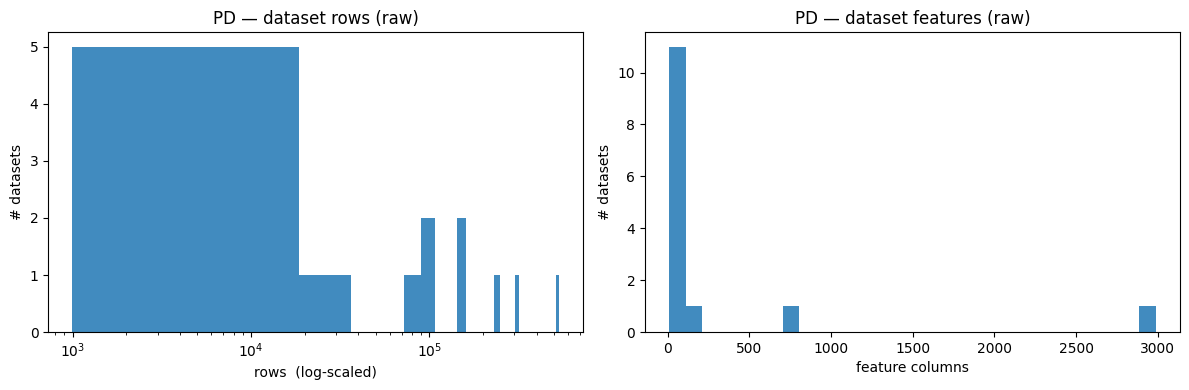

In [3]:
_ = plot_dataset_size_distribution('pd',  source='raw')

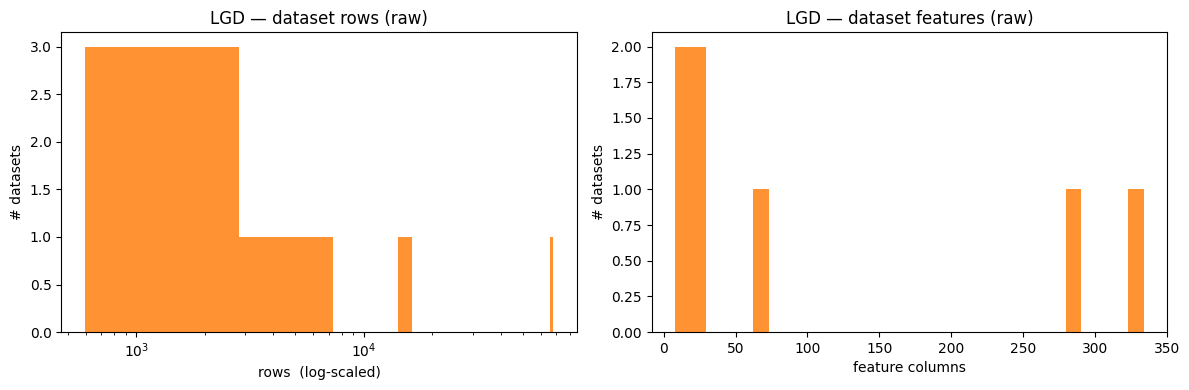

In [4]:
_ = plot_dataset_size_distribution('lgd', source='raw')

## 3. Missingness — per track

Reminder: x-axis is the **fraction of cells** in the dataset that
are NaN, denominator = `rows × features`.

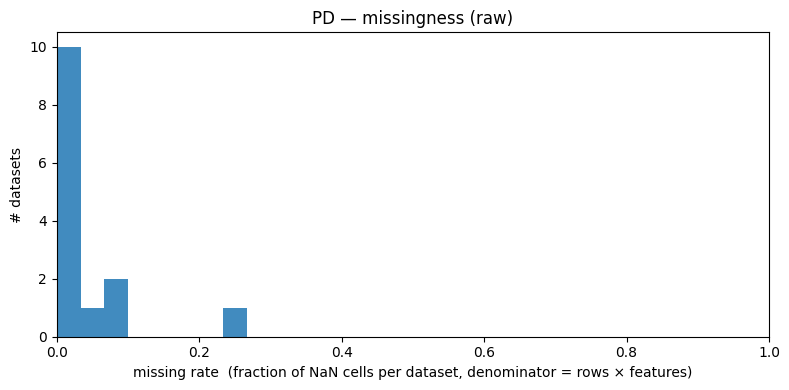

In [5]:
_ = plot_missing_rate_distribution('pd',  source='raw')

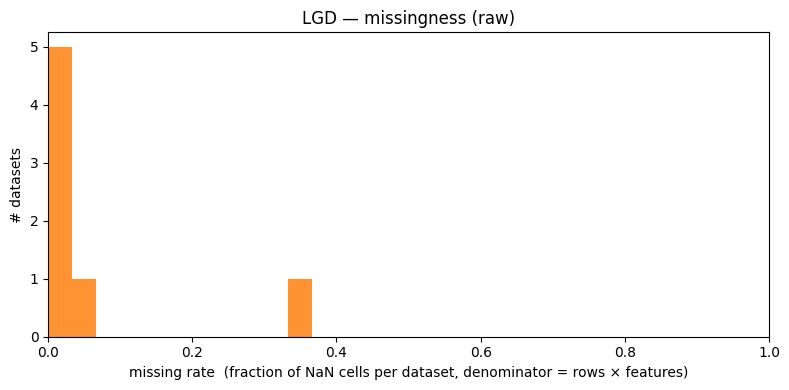

In [6]:
_ = plot_missing_rate_distribution('lgd', source='raw')

---

## 4. Per-dataset target distribution — LGD only

**Why LGD-only:** for PD the target is binary, so a per-dataset
subplot is just a 2-bar chart that adds nothing beyond the
corpus-level `minority_class_ratio` histogram in section 5. For
LGD the target is real-valued in `[0, 1]` and the interesting
structure is bimodality (mass at 0 ≡ full recovery, mass at 1 ≡
total loss, distribution of the interior) — that varies per
dataset and only a per-dataset histogram captures it.

Default: first 30 LGD datasets. Pass `dataset_ids=[...]` for a
specific subset; raise `max_show` to page further.

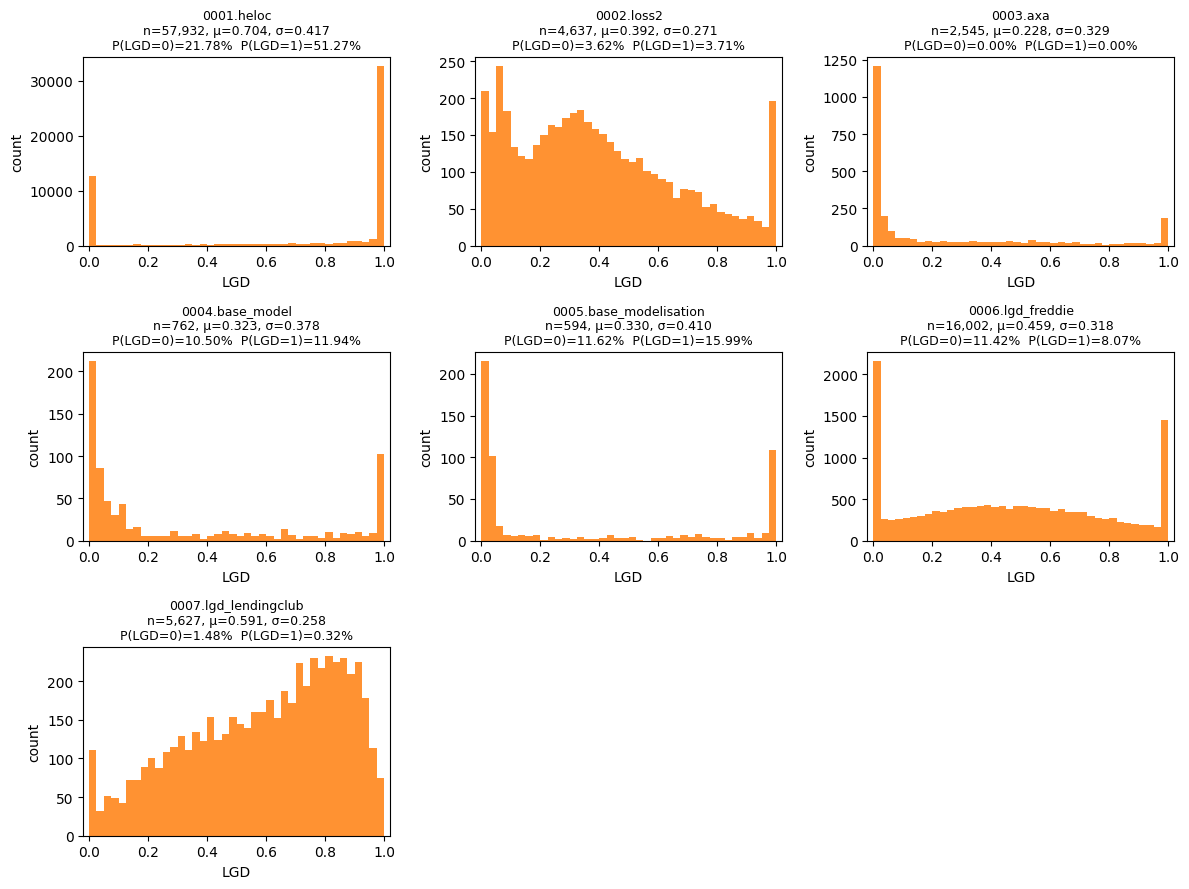

In [7]:
_ = plot_target_distribution_lgd(max_show=30)

---

## 5. Corpus-level target stats

Each dataset is a single point on these histograms. Useful at
3 000-dataset scale where per-dataset subplots don't fit a screen.

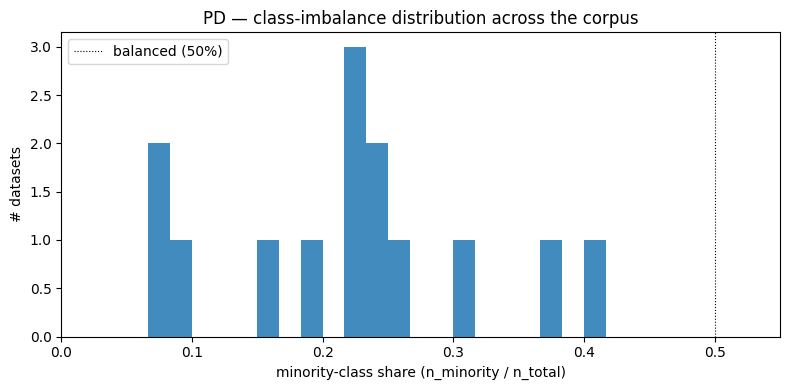

In [8]:
_ = plot_class_imbalance_distribution()

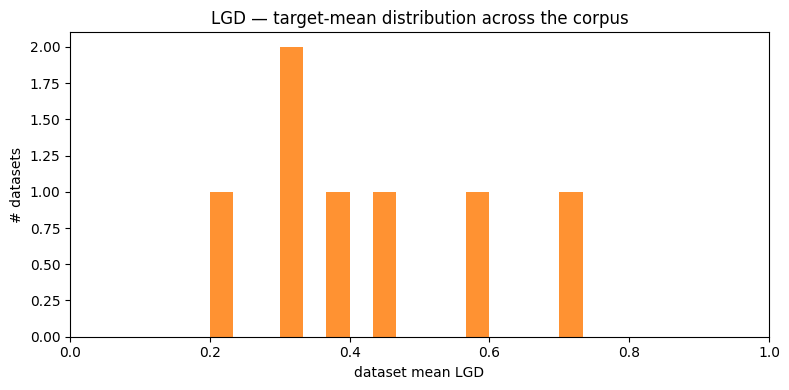

In [9]:
_ = plot_target_mean_distribution_lgd()

---

## 6. Anomaly scan

Auto-flag datasets with suspicious indicators (high missingness,
too few rows, severe imbalance, constant target, …). At 3 000-
dataset scale this is the FIRST thing you should run after every
vendor delivery.

In [10]:
anomalies = find_anomalous_datasets()
if len(anomalies) == 0:
    print('No anomalies flagged across the corpus.')
else:
    display(anomalies)

No anomalies flagged across the corpus.
